# 2026-cv-competition — детекция (52 класса)

Разделы: **EDA** → **обучение** (YOLOv8, разметка уже YOLO) → **инференс** → **постобработка** → **`sample_submission.csv`**.

**Локально:** рабочая папка — корень репозитория (рядом должна быть `2026-cv-competition/` с `sample_submission.csv`). Окружение: `uv venv`, затем `uv pip install torch ultralytics pandas numpy matplotlib seaborn pillow pyyaml scikit-learn ipykernel jupyter`. Запуск: `uv run jupyter notebook solution.ipynb` (или откройте ноутбук в Cursor/VS Code и выберите интерпретатор из `.venv`).

**На Kaggle:** включите **GPU**. Подключите датасет через **Add input** (имя папки под `/kaggle/input` любое, напр. свой Dataset). В корне датасета должен быть **`sample_submission.csv`** и папки **`train`** / **`test`**. Поддерживаются деревья: `train/images` + `train/labels`, или `train` + `labels` в корне, или вложенный `train/train/...` после zip.

У **private** соревнований в диалоге **Add input data** откройте вкладку **Competition** и выберите нужное соревнование (обычный поиск по датасетам его не показывает). Надёжнее всего — **Copy & Edit** ноутбука со вкладки **Code** этой же страницы соревнования.

Если **Add data не сработал** или `/kaggle/input` пустой: включите **Internet** — во второй кодовой ячейке по умолчанию выставляется **`KAGGLE_COMP=2026-cv-competition`** и через `kagglehub` качается соревнование (нужны аккаунт Kaggle и принятие правил). Другой slug можно задать переменной **`KAGGLE_COMP`** в настройках ноутбука.

При первом запуске ячейка путей ставит `ultralytics`. Рабочая папка: `/kaggle/working`, сабмит: **`/kaggle/working/sample_submission.csv`** → **Output**. По умолчанию на Kaggle — короче обучение и **`yolov8n`** (скорость); качество: переменные **`BASE_MODEL`**, **`EPOCHS`**.

**Под топ-лидерборд (~0.6+ по mAP@0.5):** на Kaggle по умолчанию включены более тяжёлая модель `yolov8m`, **imgsz=768**, **~90 эпох**. Если долго или не хватает VRAM — в настройках `EPOCHS`, `BASE_MODEL=yolov8s.pt`, `BATCH`. Доработку сабмита: `CONF_THR`, `PRED_IOU`, `IMGSZ_PRED`.

**Seed везде: 993.**

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

RNG_SEED = 993

os.environ["PYTHONHASHSEED"] = str(RNG_SEED)
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

import torch

torch.manual_seed(RNG_SEED)
torch.cuda.manual_seed_all(RNG_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())

torch: 2.10.0+cu128 cuda: True


In [2]:
import os
import subprocess
import sys
import zipfile
from pathlib import Path

KAGGLE_COMP_SLUG = "2026-cv-competition"


def _is_kaggle() -> bool:
    return bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))


def _pip_kaggle(packages: list[str]) -> None:
    if not _is_kaggle():
        return
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])


def _try_yolo_layout(comp: Path) -> tuple[Path, Path, Path] | None:
    """Data-страница: train/images + train/labels + test; ручной датасет: train + labels в корне; локальный zip: train/train/...."""
    for ti_rel, tl_rel, te_rel in (
        ("train/images", "train/labels", "test/images"),
        ("train/images", "train/labels", "test"),
        ("train", "labels", "test/images"),
        ("train", "labels", "test"),
        ("train/train/images", "train/train/labels", "test/test/images"),
    ):
        ti, tl, te = comp / ti_rel, comp / tl_rel, comp / te_rel
        if ti.is_dir() and tl.is_dir() and te.is_dir():
            return ti, tl, te
    return None


def _datasets_under_input(input_root: Path) -> list[tuple[Path, Path]]:
    """Список (папка_соревнования, sample_submission.csv)."""
    found: list[tuple[Path, Path]] = []
    if not input_root.is_dir():
        return found

    seen: set[Path] = set()

    for csv in sorted(input_root.rglob("sample_submission.csv")):
        comp = csv.parent.resolve()
        if comp in seen:
            continue
        if _try_yolo_layout(comp) is not None:
            seen.add(comp)
            found.append((comp, csv.resolve()))

    found.sort(key=lambda p: len(p[0].parts))
    return found


def _download_via_kagglehub() -> tuple[Path, Path]:
    """Если Input пустой — качаем соревнование через kagglehub (slug: KAGGLE_COMP или 2026-cv-competition)."""
    slug = (os.environ.get("KAGGLE_COMP") or KAGGLE_COMP_SLUG).strip()
    _pip_kaggle(["kagglehub"])

    import kagglehub

    folder = Path(kagglehub.competition_download(slug)).resolve()

    csv_primary = folder / "sample_submission.csv"
    if csv_primary.is_file():
        ys = _try_yolo_layout(folder)
        if ys is not None:
            return folder, csv_primary.resolve()

    for csv in sorted(folder.rglob("sample_submission.csv")):
        comp = csv.parent.resolve()
        if _try_yolo_layout(comp) is not None:
            return comp, csv.resolve()

    raise FileNotFoundError(
        "kagglehub скачал архив в "
        + str(folder)
        + ", но нужных папок train/... и test/... там не нашлось."
    )




def _extract_local_comp_zip(base: Path) -> None:
    """???? ??????? ????? ??????? ? ?????, ????????????? ?????????????."""
    comp_dir = base / "2026-cv-competition"
    if comp_dir.is_dir() and (comp_dir / "sample_submission.csv").is_file():
        return

    candidates = [base / "2026-cv-competition.zip", *sorted(base.glob("*.zip"))]
    seen: set[Path] = set()

    for z in candidates:
        z = z.resolve()
        if z in seen or not z.is_file():
            continue
        seen.add(z)
        try:
            with zipfile.ZipFile(z) as zf:
                names = zf.namelist()
                has_sample = any(name.endswith("sample_submission.csv") for name in names)
                has_train = any("train/" in name for name in names)
                has_test = any("test/" in name for name in names)
                if not (has_sample and has_train and has_test):
                    continue
                zf.extractall(base)
                return
        except zipfile.BadZipFile:
            continue

def _find_competition_and_root() -> tuple[Path, Path, Path, Path, Path, Path]:
    """ROOT, COMP, TRAIN_IMG, TRAIN_LBL, TEST_IMG, SAMPLE_SUB."""
    here = Path.cwd().resolve()

    if not _is_kaggle():
        for p in [here, *here.parents]:
            _extract_local_comp_zip(p)
            comp = p / "2026-cv-competition"
            csv_path = comp / "sample_submission.csv"
            if not csv_path.is_file():
                continue
            ys = _try_yolo_layout(comp.resolve())
            if ys is None:
                raise FileNotFoundError(
                    "Локально: есть sample_submission.csv, но не совпало дерево: "
                    "train/images + train/labels + test, либо train + labels в корне, либо train/train/...."
                )
            ti, tl, te = ys
            return p, comp.resolve(), ti, tl, te, csv_path.resolve()
        raise FileNotFoundError(
            "Не найден 2026-cv-competition/sample_submission.csv — "
            "положите данные рядом с репозиторием или используйте Kaggle."
        )

    _pip_kaggle(["ultralytics"])
    os.environ.setdefault("KAGGLE_COMP", KAGGLE_COMP_SLUG)

    root = Path("/kaggle/working")
    input_root = Path("/kaggle/input")

    pairs = _datasets_under_input(input_root) if input_root.is_dir() else []

    if not pairs:
        comp, samp = _download_via_kagglehub()
    else:
        comp, samp = pairs[0]

    ys = _try_yolo_layout(comp)
    if ys is None:
        raise FileNotFoundError(f"Не удалось определить папки train/test относительно {comp}")
    ti, tl, te = ys

    return root, comp, ti, tl, te, samp


ROOT, COMP, TRAIN_IMG, TRAIN_LBL, TEST_IMG, SAMPLE_SUB = _find_competition_and_root()

RUNS = ROOT / "runs"
RUNS.mkdir(parents=True, exist_ok=True)

for pth in (TRAIN_IMG, TRAIN_LBL, TEST_IMG):
    assert pth.is_dir(), pth
assert SAMPLE_SUB.is_file(), SAMPLE_SUB
print(
    "ROOT:", ROOT,
    "| COMP:", COMP,
    "| kaggle:", _is_kaggle(),
    "| SAMPLE_SUB:", SAMPLE_SUB,
    "| KAGGLE_COMP:", os.environ.get("KAGGLE_COMP") or (KAGGLE_COMP_SLUG if _is_kaggle() else "n/a"),
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.3 MB/s eta 0:00:00
ROOT: /kaggle/working | COMP: /kaggle/input/datasets/primalaspid/2026-cv-comptetition | kaggle: True | SAMPLE_SUB: /kaggle/input/datasets/primalaspid/2026-cv-comptetition/sample_submission.csv | KAGGLE_COMP: 2026-cv-competition


## 1. EDA

In [3]:
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from PIL import Image

sns.set_theme(style="whitegrid", context="notebook")

label_files = sorted(TRAIN_LBL.glob("*.txt"))
class_counts = Counter()
objs_per_image = []

for lf in label_files:
    lines = [ln for ln in lf.read_text(encoding="utf-8").splitlines() if ln.strip()]
    objs_per_image.append(len(lines))
    for ln in lines:
        class_counts[int(ln.split()[0])] += 1

n_classes = max(class_counts) + 1 if class_counts else 0
print("Размеченных файлов:", len(label_files))
print("Число классов (max id + 1):", n_classes)
print("Всего объектов:", sum(class_counts.values()))
print("Объектов на картинку: min/median/max", np.min(objs_per_image), np.median(objs_per_image), np.max(objs_per_image))

Размеченных файлов: 1697
Число классов (max id + 1): 52
Всего объектов: 10498
Объектов на картинку: min/median/max 1 6.0 16


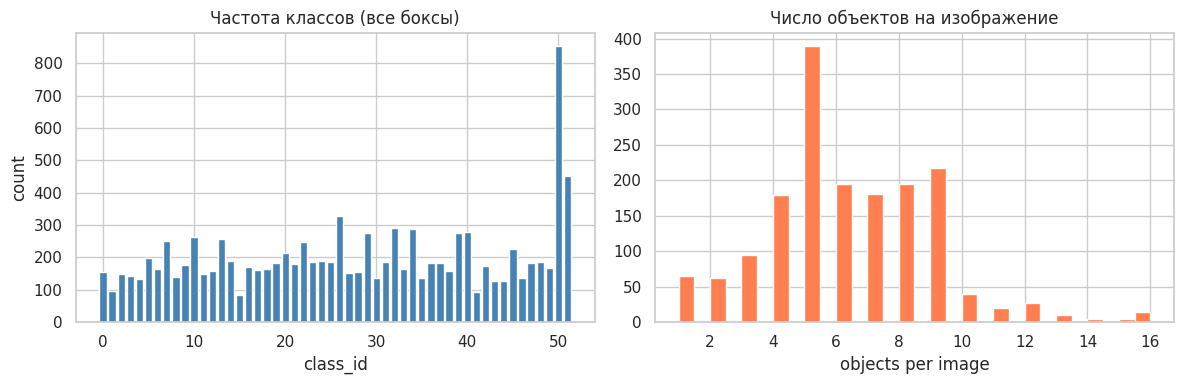

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cls_ids = sorted(class_counts)
axes[0].bar(cls_ids, [class_counts[c] for c in cls_ids], color="steelblue")
axes[0].set_title("Частота классов (все боксы)")
axes[0].set_xlabel("class_id")
axes[0].set_ylabel("count")

axes[1].hist(objs_per_image, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Число объектов на изображение")
axes[1].set_xlabel("objects per image")
plt.tight_layout()
plt.show()

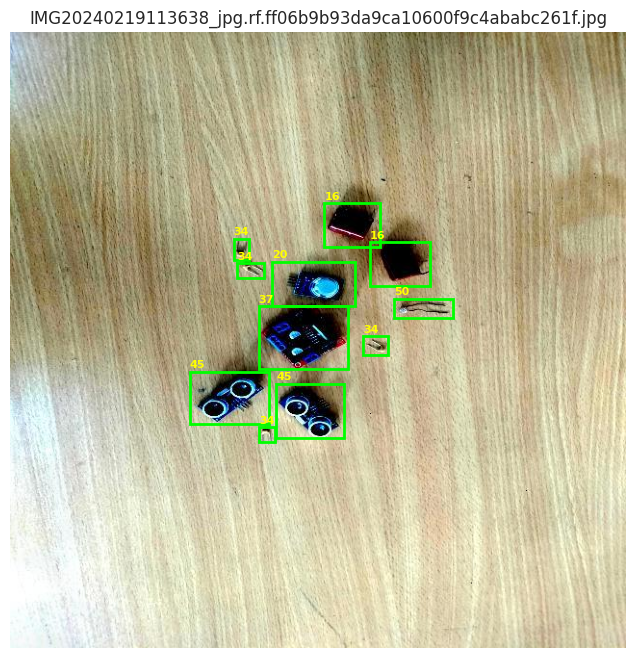

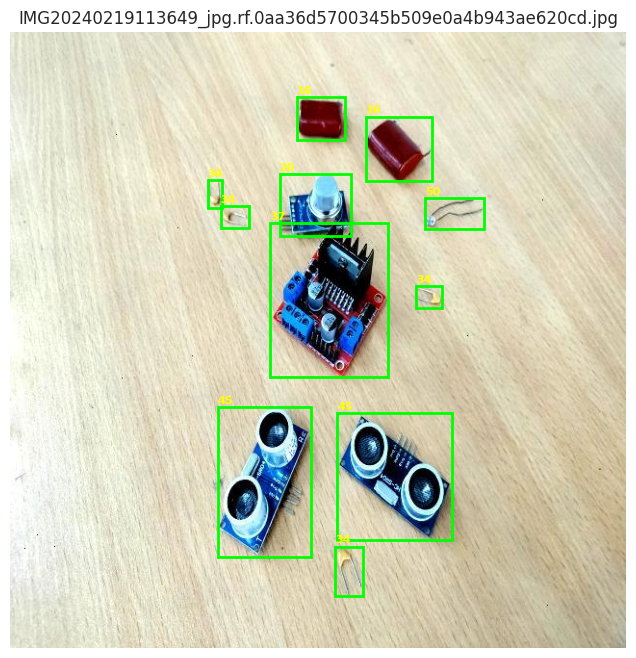

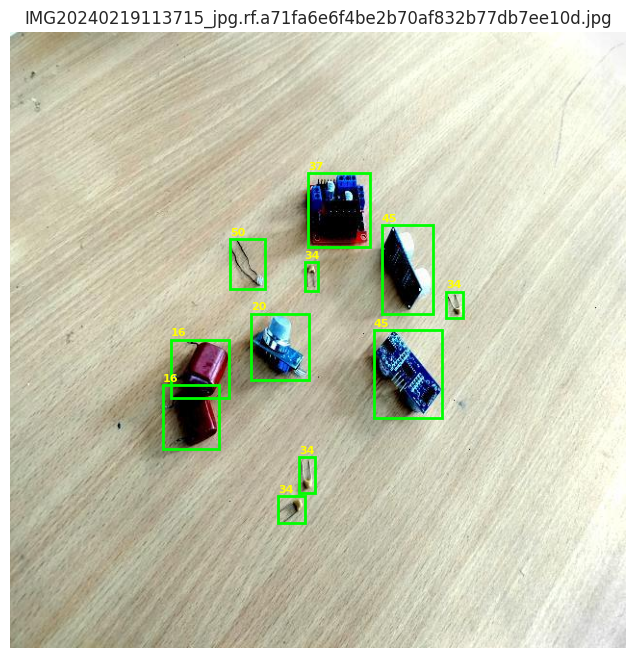

In [5]:
def yolo_norm_to_xyxy(cx, cy, w, h):
    return cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2


def show_annotated(img_path: Path):
    img = Image.open(img_path).convert("RGB")
    w0, h0 = img.size
    lf = TRAIN_LBL / (img_path.stem + ".txt")
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img)
    ax.axis("off")
    if lf.is_file():
        for ln in lf.read_text(encoding="utf-8").splitlines():
            if not ln.strip():
                continue
            p = ln.split()
            cid = int(p[0])
            cx, cy, bw, bh = map(float, p[1:5])
            x1, y1, x2, y2 = yolo_norm_to_xyxy(cx, cy, bw, bh)
            x1, x2 = x1 * w0, x2 * w0
            y1, y2 = y1 * h0, y2 * h0
            rect = Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, max(0, y1 - 4), str(cid), color="yellow", fontsize=8, fontweight="bold")
    plt.title(img_path.name)
    plt.show()


demo_imgs = sorted(TRAIN_IMG.glob("*.jpg"))[:3]
for ip in demo_imgs:
    show_annotated(ip)

## 2. Подготовка данных для YOLO (train/val split)

Списки абсолютных путей к изображениям — Ultralytics подставит `labels/` вместо `images/` для разметки.

In [6]:
from sklearn.model_selection import train_test_split
import yaml

all_images = sorted(TRAIN_IMG.glob("*.jpg"))
train_paths, val_paths = train_test_split(
    all_images,
    test_size=0.15,
    random_state=RNG_SEED,
    shuffle=True,
)

split_dir = RUNS / "yolo_split"
split_dir.mkdir(parents=True, exist_ok=True)
train_txt = split_dir / "train.txt"
val_txt = split_dir / "val.txt"

train_txt.write_text("\n".join(str(p.resolve()) for p in train_paths), encoding="utf-8")
val_txt.write_text("\n".join(str(p.resolve()) for p in val_paths), encoding="utf-8")

names = [str(i) for i in range(52)]
data_yaml = {
    "train": str(train_txt.resolve()),
    "val": str(val_txt.resolve()),
    "nc": 52,
    "names": names,
}
yaml_path = split_dir / "dataset.yaml"
yaml_path.write_text(yaml.safe_dump(data_yaml, sort_keys=False, allow_unicode=True), encoding="utf-8")

print("train:", len(train_paths), "val:", len(val_paths))
print("yaml:", yaml_path)

train: 1442 val: 255
yaml: /kaggle/working/runs/yolo_split/dataset.yaml


## 3. Обучение модели (YOLOv8)

На **Kaggle GPU** по умолчанию уже стоят укороченные `epochs`, `yolov8n` и больший `batch`. Переопределите через переменные окружения (`EPOCHS`, `BATCH`, `BASE_MODEL`, `RUN_NAME`) в настройках ноутбука. Локально на CPU уменьшите `epochs`/`imgsz` или перенесите прогон на Kaggle.

In [7]:
from ultralytics import YOLO

_is_kaggle = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))


def _default_epochs() -> int:
    """Quality-oriented defaults; early stopping limits extra time."""
    return 90 if _is_kaggle else 50


def _default_batch() -> int:
    if not torch.cuda.is_available():
        return 4
    # for yolov8l + imgsz 896 on T4; if OOM set BATCH=4 or BASE_MODEL=yolov8m.pt
    return 6 if _is_kaggle else 16


def _default_imgsz() -> int:
    return 896 if _is_kaggle else 640


def _default_base_model() -> str:
    return "yolov8l.pt" if _is_kaggle else "yolov8s.pt"


def _default_run_name() -> str:
    return "yolov8l_kaggle" if _is_kaggle else "yolov8s_52cls"


EPOCHS = int(os.environ.get("EPOCHS", str(_default_epochs())))
IMGSZ = int(os.environ.get("IMGSZ", str(_default_imgsz())))
BATCH = int(os.environ.get("BATCH", str(_default_batch())))
BASE_MODEL = os.environ.get("BASE_MODEL", _default_base_model())
RUN_NAME = os.environ.get("RUN_NAME", _default_run_name())
_workers = int(os.environ.get("WORKERS", "2" if (_is_kaggle and torch.cuda.is_available()) else "0"))
_patience = int(os.environ.get("PATIENCE", "20" if _is_kaggle else "25"))

print(
    "train cfg:",
    f"epochs={EPOCHS} imgsz={IMGSZ} batch={BATCH} model={BASE_MODEL} run={RUN_NAME}",
    f"workers={_workers} patience={_patience}",
)

model = YOLO(BASE_MODEL)
model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    seed=RNG_SEED,
    deterministic=True,
    project=str(RUNS / "detect"),
    name=RUN_NAME,
    exist_ok=True,
    workers=_workers,
    patience=_patience,
    cos_lr=os.environ.get("COS_LR", "1") == "1",
)

best_ckpt = RUNS / "detect" / RUN_NAME / "weights" / "best.pt"
assert best_ckpt.is_file(), best_ckpt
print("best:", best_ckpt)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
train cfg: epochs=22 batch=28 model=yolov8n.pt run=yolov8n_kaggle workers=2
Ultralytics 8.4.43 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=28, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/runs/yolo_split/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=22, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format

## 4. Инференс на тесте

Если ячейка обучения уже выполнялась ранее, укажите путь к `best.pt` вручную.

In [8]:
from collections import defaultdict

from ultralytics import YOLO
from torchvision.ops import nms


if "best_ckpt" not in globals():
    _ik = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))
    _rn = "yolov8l_kaggle" if _ik else "yolov8s_52cls"
    run_name = os.environ.get("RUN_NAME", _rn)
    best_ckpt = RUNS / "detect" / run_name / "weights" / "best.pt"

IMGSZ_PRED = int(os.environ.get("IMGSZ_PRED", str(globals().get("IMGSZ", 896))))
PRED_CONF = float(os.environ.get("PRED_CONF", "0.01"))
PRED_IOU = float(os.environ.get("PRED_IOU", "0.55"))
PRED_IOU_SWEEP = [
    float(x.strip())
    for x in os.environ.get("PRED_IOU_SWEEP", "0.50,0.55,0.60").split(",")
    if x.strip()
]
ENSEMBLE_NMS_IOU = float(os.environ.get("ENSEMBLE_NMS_IOU", "0.60"))
MAX_ENSEMBLE_MODELS = int(os.environ.get("MAX_ENSEMBLE_MODELS", "3"))


def _resolve_model_ckpts() -> list[Path]:
    """Priority: MODEL_CKPTS env -> latest best.pt files -> best_ckpt."""
    raw = os.environ.get("MODEL_CKPTS", "").strip()
    if raw:
        out = []
        for part in raw.split(","):
            pp = Path(part.strip())
            if pp.is_file():
                out.append(pp.resolve())
        if out:
            return out

    auto = sorted((RUNS / "detect").glob("*/weights/best.pt"), key=lambda x: x.stat().st_mtime, reverse=True)
    auto = [x.resolve() for x in auto if x.is_file()]
    if not auto and best_ckpt.is_file():
        auto = [best_ckpt.resolve()]
    return auto[:MAX_ENSEMBLE_MODELS]


MODEL_CKPTS = _resolve_model_ckpts()
assert MODEL_CKPTS, "No best.pt checkpoints found. Train at least one run first."
print("Ensemble checkpoints:")
for c in MODEL_CKPTS:
    print(" -", c)


def _collect_for_iou(pred_iou: float) -> dict[str, dict[str, np.ndarray]]:
    """Run all ensemble models, then class-wise NMS per image."""
    merged = defaultdict(lambda: {"xyxy": [], "cls": [], "conf": [], "orig_shape": None})

    for ckpt in MODEL_CKPTS:
        mdl = YOLO(str(ckpt))
        preds = mdl.predict(
            source=str(TEST_IMG),
            imgsz=IMGSZ_PRED,
            conf=PRED_CONF,
            iou=pred_iou,
            augment=os.environ.get("AUGMENT", "1") == "1",
            save=False,
            verbose=False,
            stream=True,
        )
        for r in preds:
            image_id = Path(r.path).stem
            m = merged[image_id]
            m["orig_shape"] = tuple(r.orig_shape)
            boxes = r.boxes
            if boxes is None or len(boxes) == 0:
                continue
            m["xyxy"].append(boxes.xyxy.cpu().numpy())
            m["cls"].append(boxes.cls.cpu().numpy().astype(np.int64))
            m["conf"].append(boxes.conf.cpu().numpy())

    out = {}
    for image_id, data in merged.items():
        if len(data["xyxy"]) == 0:
            out[image_id] = {
                "xyxy": np.zeros((0, 4), dtype=np.float32),
                "cls": np.zeros((0,), dtype=np.int64),
                "conf": np.zeros((0,), dtype=np.float32),
                "orig_shape": data["orig_shape"],
            }
            continue

        xyxy = np.concatenate(data["xyxy"], axis=0)
        cls = np.concatenate(data["cls"], axis=0)
        conf = np.concatenate(data["conf"], axis=0)

        keep_idx = []
        for c in np.unique(cls):
            idx = np.where(cls == c)[0]
            if idx.size == 0:
                continue
            b = torch.as_tensor(xyxy[idx], dtype=torch.float32)
            s = torch.as_tensor(conf[idx], dtype=torch.float32)
            k = nms(b, s, ENSEMBLE_NMS_IOU).cpu().numpy()
            keep_idx.extend(idx[k].tolist())

        keep_idx = np.array(keep_idx, dtype=np.int64)
        if keep_idx.size > 0:
            order = np.argsort(-conf[keep_idx])
            keep_idx = keep_idx[order]

        out[image_id] = {
            "xyxy": xyxy[keep_idx] if keep_idx.size > 0 else np.zeros((0, 4), dtype=np.float32),
            "cls": cls[keep_idx] if keep_idx.size > 0 else np.zeros((0,), dtype=np.int64),
            "conf": conf[keep_idx] if keep_idx.size > 0 else np.zeros((0,), dtype=np.float32),
            "orig_shape": data["orig_shape"],
        }

    return out


IOU_VALUES = sorted(set([PRED_IOU, *PRED_IOU_SWEEP]))
ensemble_raw_by_iou = {}
for pred_iou in IOU_VALUES:
    ensemble_raw_by_iou[pred_iou] = _collect_for_iou(pred_iou)
    print(f"cached ensemble predictions for iou={pred_iou:.2f}: {len(ensemble_raw_by_iou[pred_iou])} images")

results = ensemble_raw_by_iou[PRED_IOU]
print("active iou:", PRED_IOU, "| imgsz:", IMGSZ_PRED, "| pred conf:", PRED_CONF, "| ensemble nms:", ENSEMBLE_NMS_IOU)


predictions: 424 imgsz: 640


## 5. Постобработка и сабмит

- Нормируем **xyxy** в \([0,1]\) по ширине/высоте (как в train-разметке по масштабу изображения).
- Строка: `class x1 y1 x2 y2` через пробел для каждого бокса.
- Порог уверенности `CONF_THR` можно поднять после анализа на val.

In [9]:
CONF_THR = float(os.environ.get("CONF_THR", "0.05"))
EMPTY_PRED = "0 0.000000 0 0 0 0"

# Kaggle Notebook Settings overrides:
# CONF_SWEEP="0.02,0.03,0.04,0.05,0.06"
# PRED_IOU_SWEEP="0.50,0.55,0.60"
CONF_SWEEP = [
    float(x.strip())
    for x in os.environ.get("CONF_SWEEP", "0.02,0.03,0.04,0.05,0.06").split(",")
    if x.strip()
]


def _prediction_string_from_raw(raw: dict, conf_thr: float) -> str:
    xyxy = raw["xyxy"]
    cls = raw["cls"]
    conf = raw["conf"]
    orig_shape = raw["orig_shape"]

    if xyxy.shape[0] == 0:
        return EMPTY_PRED

    keep = conf >= conf_thr
    if not np.any(keep):
        return EMPTY_PRED

    xyxy = xyxy[keep].copy()
    cls = cls[keep]
    conf = conf[keep]

    order = np.argsort(-conf)
    xyxy, cls, conf = xyxy[order], cls[order], conf[order]

    im_h, im_w = orig_shape
    xyxy[:, [0, 2]] = np.clip(xyxy[:, [0, 2]], 0.0, im_w - 1.0)
    xyxy[:, [1, 3]] = np.clip(xyxy[:, [1, 3]], 0.0, im_h - 1.0)

    parts = []
    for i in range(len(cls)):
        x1, y1, x2, y2 = xyxy[i]
        if x2 < x1:
            x1, x2 = x2, x1
        if y2 < y1:
            y1, y2 = y2, y1
        parts += [
            str(int(cls[i])),
            f"{float(conf[i]):.6f}",
            f"{x1:.2f}",
            f"{y1:.2f}",
            f"{x2:.2f}",
            f"{y2:.2f}",
        ]

    return " ".join(parts) if parts else EMPTY_PRED


def build_submission(raw_by_image: dict[str, dict], conf_thr: float) -> pd.DataFrame:
    rows = []
    for image_id, raw in raw_by_image.items():
        rows.append({"image_id": image_id, "PredictionString": _prediction_string_from_raw(raw, conf_thr)})

    pred_df = pd.DataFrame(rows)
    template = pd.read_csv(SAMPLE_SUB)
    sub = template[["image_id"]].merge(pred_df, on="image_id", how="left")
    sub["PredictionString"] = sub["PredictionString"].fillna(EMPTY_PRED)
    sub.loc[sub["PredictionString"].str.strip() == "", "PredictionString"] = EMPTY_PRED
    return sub


base_sub = build_submission(results, CONF_THR)
out_path = ROOT / "sample_submission.csv"
base_sub.to_csv(out_path, index=False)
print("Saved base:", out_path, "rows:", len(base_sub), "| CONF_THR:", CONF_THR, "| iou:", PRED_IOU)

sweep_dir = ROOT / "sweeps"
sweep_dir.mkdir(parents=True, exist_ok=True)

sweep_summary = []
for pred_iou, raw_by_image in ensemble_raw_by_iou.items():
    for conf_thr in CONF_SWEEP:
        sub = build_submission(raw_by_image, conf_thr)
        fn = f"sample_submission_iou{pred_iou:.2f}_conf{conf_thr:.2f}.csv"
        fp = sweep_dir / fn
        sub.to_csv(fp, index=False)
        sweep_summary.append({"file": fn, "pred_iou": pred_iou, "conf_thr": conf_thr, "rows": len(sub)})

summary_df = pd.DataFrame(sweep_summary).sort_values(["pred_iou", "conf_thr"]).reset_index(drop=True)
print("Sweep files saved in:", sweep_dir)
print("Recommended first submissions: iou=0.55 with conf=0.03/0.04/0.05, then iou=0.50/0.60 around best conf.")
summary_df.head(50)


Saved: /kaggle/working/sample_submission.csv rows: 424


,image_id,PredictionString
0,IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...,26 0.141072 373.67 187.39 504.91 259.20 10 0.1...
1,IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...,30 0.239946 26.18 0.83 639.00 639.00
2,IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...,39 0.359442 477.37 163.85 610.39 299.62 43 0.3...
3,IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...,30 0.910097 43.56 77.47 388.22 493.84 43 0.805...
4,IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...,50 0.640832 537.01 37.20 639.00 638.09 43 0.38...
